In [1]:
from brian2 import *
import numpy as np

start_scope()
defaultclock.dt = 0.1*ms
### neuron model parameters ###
C = 200*pF
g_leak = 10*nS
tau = 20*ms
V_rest = -60*mV
reversal_P = 0*mV
reversal_B = -70*mV
reversal_A = -70*mV
V_th = -50*mV
V_reset = -60*mV

### synapse parameters ###
synaptic_delay = 1*ms

tau_syn_P = 2*ms
tau_syn_A = 4*ms
tau_syn_B = 1.5*ms

tau_D = 250*ms
eta_D = 0.18
e_AB = 0.5

# synapric conductance increases and connection probabilities
g_PP = 0.2*nS
p_PP = 0.01

g_PA = 6*nS
p_PA = 0.6

g_PB = 0.7*nS
p_PB = 0.5

g_AP = 0.2*nS
p_AP = 0.01

g_AA = 4*nS
p_AA = 0.6

g_AB = 8*nS
p_AB = 0.2

g_BP = 0.05*nS
p_BP = 0.2

g_BA = 7*nS
p_BA = 0.6

g_BB = 5*nS
p_BB =0.2

# population sizes
N_P = 8200
N_B = 135
N_A = 50

### currents ###
I_BG = 200*pA
I_i = 0*pA
I_ext = I_BG + I_i



### equations ###
eqs = '''
dv/dt = (g_leak*(V_rest - v) - (g_P*(v-reversal_P) + g_A*(v-reversal_A) + g_B*(v-reversal_B)) + I_ext)/C : volt (unless refractory)
dg_P/dt = -g_P/tau_syn_P : siemens
dg_A/dt = -g_A/tau_syn_A : siemens
dg_B/dt = -g_B/tau_syn_B : siemens
'''

#d - 
### neurons groups ###
group_P = NeuronGroup(N_P, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')
group_A = NeuronGroup(N_A, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')
group_B = NeuronGroup(N_B, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')

### synapses ###
synapse_PP = Synapses(group_P, group_P, on_pre='g_P_post += g_PP', delay=synaptic_delay)
synapse_PP.connect(p=p_PP)

synapse_AP = Synapses(group_P, group_A, on_pre='g_P_post += g_AP', delay=synaptic_delay)
synapse_AP.connect(p=p_AP)

synapse_BP = Synapses(group_P, group_B, on_pre='g_P_post += g_BP', delay=synaptic_delay)
synapse_BP.connect(p=p_BP)


synapse_AA = Synapses(group_A, group_A, on_pre='g_A_post += g_AA', delay=synaptic_delay)
synapse_AA.connect(p=p_AA)

synapse_PA = Synapses(group_A, group_P, on_pre='g_A_post += g_PA', delay=synaptic_delay)
synapse_PA.connect(p=p_PA)

synapse_BA = Synapses(group_A, group_B, on_pre='g_A_post += g_BA', delay=synaptic_delay)
synapse_BA.connect(p=p_BA)



synapse_BB = Synapses(group_B, group_B, on_pre='g_B_post += g_BB', delay=synaptic_delay)
synapse_BB.connect(p=p_BB)


# to control depression
clamp_depr = 0
eqs_std_AB = '''
       g_ab : 1
       de_AB / dt = clamp_depr * (1. - e_AB) / tau_D : 1 (clock-driven)
       '''

synapse_AB = Synapses(group_B, group_A, model=eqs_std_AB, on_pre='''
                    g_B_post += g_AB*e_AB
                    e_AB = clip(e_AB - e_AB * eta_D, 0, 1)
                      ''', method='exact', delay=synaptic_delay)
synapse_AB.connect(p=p_AB)

synapse_PB = Synapses(group_B, group_P, on_pre='g_B_post += g_PB', delay=synaptic_delay)
synapse_PB.connect(p=p_PB)


group_P.v = V_rest
group_B.v = V_rest
group_A.v = V_rest + (V_th - V_rest) * np.random.rand(N_A)


# Initialize synaptic conductances with small random values
group_P.g_P = 0.01 * nS * np.random.rand(N_P)
group_A.g_A = 0.01 * nS * np.random.rand(N_A)
group_B.g_B = 0.01 * nS * np.random.rand(N_B)

# Add PopulationRateMonitors
pop_rate_P = PopulationRateMonitor(group_P)
pop_rate_A = PopulationRateMonitor(group_A)
pop_rate_B = PopulationRateMonitor(group_B)



# Run the simulation
run(2000*ms)

/Users/maxnowa/Library/Caches/cython/brian_extensions/_cython_magic_b10b5f3b633a01bd939122e0d32c99b4.cpp:1298:14: fatal error: 'cstdlib' file not found
 1298 |     #include <cstdlib>
      |              ^~~~~~~~~
1 error generated.
WARNING    Cannot use Cython, a test compilation failed: command '/usr/bin/clang' failed with exit code 1 (CompileError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]
WARNING    'e_AB' is an internal variable

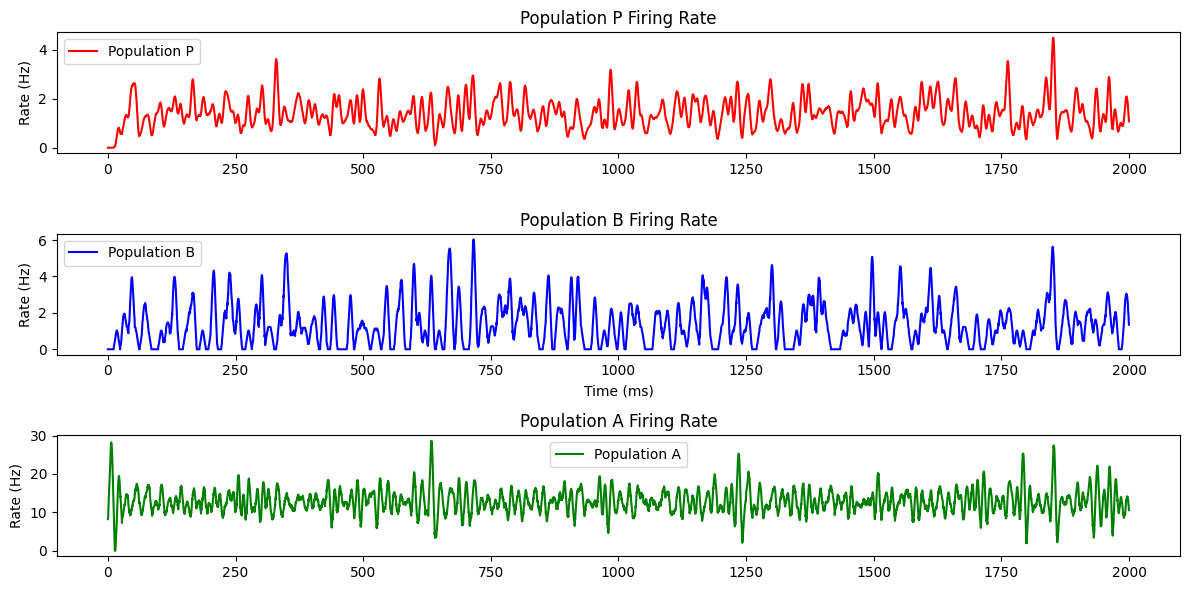

In [2]:
import matplotlib.pyplot as plt


# Plot population rates
plt.figure(figsize=(12, 6))

# Population P
plt.subplot(3, 1, 1)
plt.plot(pop_rate_P.t/ms, pop_rate_P.smooth_rate(window="gaussian", width=3*ms)/Hz, label='Population P', color="red")
plt.ylabel('Rate (Hz)')

plt.title('Population P Firing Rate')
plt.legend()


# Population B
plt.subplot(3, 1, 2)
plt.plot(pop_rate_B.t/ms, pop_rate_B.smooth_rate(window="gaussian", width=3*ms)/Hz, label='Population B', color='blue')
plt.xlabel('Time (ms)')
plt.ylabel('Rate (Hz)')
plt.title('Population B Firing Rate')
plt.legend()

# Population A
plt.subplot(3, 1, 3)
plt.plot(pop_rate_A.t/ms, pop_rate_A.smooth_rate(window="gaussian", width=3*ms)/Hz, label='Population A', color='green')
plt.ylabel('Rate (Hz)')

plt.title('Population A Firing Rate')
plt.legend()

plt.tight_layout()
plt.show()

